In [1]:
import numpy as np
import pandas as pd

In [4]:
train_df = pd.read_csv("/content/train.csv")

In [5]:
train_df.head()

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.21,0.00,0.42,0.25,0.12,-0.021782,1.981251,0.020036,0.140315,1.032029,...,0.489143,0.607589,0.321670,-1.236055,1.601132,1.384662,0.305850,0.193460,0.580374,-0.762738
1,0.02,0.33,0.19,0.46,0.00,-0.224339,1.148036,-1.107840,0.149533,-0.354000,...,-1.257481,-1.475283,-0.437385,-1.402911,0.147941,-1.143244,-0.439171,-1.379041,-1.280989,-0.503625
2,0.08,0.08,0.18,0.50,0.16,0.457763,0.242591,-0.922492,0.908213,0.972003,...,1.784349,0.450467,0.622687,1.375614,-0.428790,1.161616,0.601289,0.872950,0.660000,2.024576
3,0.25,0.42,0.00,0.07,0.26,-0.577734,-0.930826,0.815284,0.447514,0.455717,...,-0.066422,0.483730,-1.865442,-0.046295,-0.163820,-0.209693,-1.840566,0.300293,-0.351336,-1.551914
4,0.26,0.16,0.08,0.50,0.00,0.120415,0.666268,-0.626934,2.725357,0.392259,...,-0.118913,-1.172398,0.301785,-1.787407,-0.493361,-0.528049,0.286344,-0.265192,0.430513,0.735073


In [6]:
test_df = pd.read_csv("/content/test.csv")

In [7]:
test_df.head()

,ID,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,...,Component1_Property9,Component2_Property9,Component3_Property9,Component4_Property9,Component5_Property9,Component1_Property10,Component2_Property10,Component3_Property10,Component4_Property10,Component5_Property10
0,1,0.18,0.05,0.32,0.37,0.08,-0.177804,-0.741219,0.769821,-0.877069,...,-0.265376,0.123432,0.028533,-0.173365,1.297923,0.323299,-0.315146,0.625518,-0.514342,-0.777057
1,2,0.00,0.50,0.00,0.37,0.13,2.501354,0.177344,-0.498739,-0.196742,...,-0.787677,-0.757905,-0.280561,-1.965970,0.543475,-0.906851,0.962341,-0.183757,0.310871,-1.329042
2,3,0.16,0.00,0.17,0.50,0.17,1.547324,0.891479,0.030627,-0.368678,...,-0.710026,-1.422693,0.874071,-1.016144,0.093525,1.048525,-1.321851,0.356640,-0.869543,-0.177255
3,4,0.50,0.00,0.17,0.16,0.17,-0.424427,1.016862,-1.182979,-0.854225,...,-0.551366,0.257105,-0.077337,-0.721031,-0.760365,-0.507690,1.346556,-0.001529,-1.008445,1.726105
4,5,0.00,0.00,0.50,0.50,0.00,-0.187062,-0.762173,-0.473660,2.074087,...,-1.811468,-0.181223,-0.475933,0.234775,-0.909020,1.238203,-1.805664,0.980417,-1.354932,-0.657513


In [9]:
solution_df = pd.read_csv("/content/sample_solution.csv")

In [10]:
solution_df.head()

,ID,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,1,-0.117370,0.348090,0.473673,0.079501,-0.411504,0.015352,0.454957,0.065651,-0.146684,-0.140500
1,2,-0.503910,-0.250186,-1.412727,-0.523577,-0.577571,-0.294264,-1.396187,-0.856044,-0.003241,-0.246948
2,3,1.484172,1.272972,1.188539,1.321349,1.472491,1.237584,1.192748,1.575889,0.773926,1.917254
3,4,0.841616,0.457436,0.534375,0.376650,1.593406,0.157950,0.516430,0.632370,0.376289,-0.446052
4,5,-0.024147,0.136198,1.174866,-0.197264,2.463520,0.418315,1.185596,0.509797,-0.434762,0.807128


In [11]:
solution_df.shape

(500, 11)

In [12]:
train_df.isna().sum()

,0
Component1_fraction,0
Component2_fraction,0
Component3_fraction,0
Component4_fraction,0
Component5_fraction,0
...,...
BlendProperty6,0
BlendProperty7,0
BlendProperty8,0
BlendProperty9,0


In [13]:
test_df.isna().sum()

,0
ID,0
Component1_fraction,0
Component2_fraction,0
Component3_fraction,0
Component4_fraction,0
Component5_fraction,0
Component1_Property1,0
Component2_Property1,0
Component3_Property1,0
Component4_Property1,0


In [14]:
train_df.duplicated().sum()

np.int64(0)

In [15]:
test_df.duplicated().sum()

np.int64(0)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
x_train = train_df.drop(['BlendProperty1','BlendProperty2','BlendProperty3','BlendProperty4','BlendProperty5','BlendProperty6','BlendProperty7','BlendProperty8','BlendProperty9','BlendProperty10'],axis=1)

In [18]:
x_train

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,Component1_Property9,Component2_Property9,Component3_Property9,Component4_Property9,Component5_Property9,Component1_Property10,Component2_Property10,Component3_Property10,Component4_Property10,Component5_Property10
0,0.21,0.00,0.42,0.25,0.12,-0.021782,1.981251,0.020036,0.140315,1.032029,...,0.480368,1.044967,-0.450956,0.674572,-0.636394,-1.244963,-1.355050,-0.314423,0.993593,-2.728928
1,0.02,0.33,0.19,0.46,0.00,-0.224339,1.148036,-1.107840,0.149533,-0.354000,...,-1.958826,-0.019603,-0.807923,0.148715,1.439313,-1.160435,-0.014276,-0.135968,-1.221155,0.896222
2,0.08,0.08,0.18,0.50,0.16,0.457763,0.242591,-0.922492,0.908213,0.972003,...,-0.798978,-0.444027,0.148405,-0.793607,0.123834,0.006829,0.668734,0.015449,-0.098661,-0.424314
3,0.25,0.42,0.00,0.07,0.26,-0.577734,-0.930826,0.815284,0.447514,0.455717,...,-0.534135,1.155513,-0.760428,0.450159,-0.973779,0.052972,-1.024785,0.118951,2.400556,-0.576430
4,0.26,0.16,0.08,0.50,0.00,0.120415,0.666268,-0.626934,2.725357,0.392259,...,-0.389350,1.799238,-0.912374,1.767557,-0.467038,2.104922,0.858593,-0.469110,0.715789,-2.038341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.50,0.12,0.00,0.26,0.12,0.279523,-0.054170,-0.391227,0.400222,1.032029,...,1.138839,1.666804,-1.413339,0.405253,0.766653,-0.322096,1.399468,1.096369,-0.346225,0.641193
1996,0.19,0.31,0.00,0.37,0.13,-0.887185,0.610050,0.178606,1.083154,-2.822749,...,-0.782418,0.784366,1.113626,1.328112,-2.537512,0.461525,0.647984,-0.618766,-0.047918,0.397253
1997,0.38,0.06,0.14,0.31,0.11,0.568978,-0.196759,-0.646318,-0.980070,1.032029,...,-0.813747,-0.197880,-0.549162,0.810814,1.567580,-0.694918,-1.710215,-0.233936,-0.133002,-0.284672
1998,0.50,0.16,0.00,0.18,0.16,-0.067453,0.321977,-0.137535,0.238507,0.017455,...,1.262477,-0.925444,-0.823345,0.427648,-0.161447,0.628131,-0.038484,0.343058,0.448748,0.193507


In [19]:
y_train = train_df[['BlendProperty1','BlendProperty2','BlendProperty3','BlendProperty4','BlendProperty5','BlendProperty6','BlendProperty7','BlendProperty8','BlendProperty9','BlendProperty10']]

In [20]:
y_train

,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.489143,0.607589,0.321670,-1.236055,1.601132,1.384662,0.305850,0.193460,0.580374,-0.762738
1,-1.257481,-1.475283,-0.437385,-1.402911,0.147941,-1.143244,-0.439171,-1.379041,-1.280989,-0.503625
2,1.784349,0.450467,0.622687,1.375614,-0.428790,1.161616,0.601289,0.872950,0.660000,2.024576
3,-0.066422,0.483730,-1.865442,-0.046295,-0.163820,-0.209693,-1.840566,0.300293,-0.351336,-1.551914
4,-0.118913,-1.172398,0.301785,-1.787407,-0.493361,-0.528049,0.286344,-0.265192,0.430513,0.735073
...,...,...,...,...,...,...,...,...,...,...
1995,-0.028366,-0.327297,-0.316933,-1.294092,-0.530259,-0.421526,-0.320869,0.709627,-0.737244,-0.744289
1996,-0.449245,0.156778,-0.367445,-0.938615,-0.577451,-0.209996,-0.370505,-0.195531,-0.032834,0.269718
1997,0.029135,0.164890,-0.092942,-1.134490,-0.437479,-0.695636,-0.101073,0.063650,0.624368,-0.477053
1998,-0.232960,-0.464947,0.112536,-0.793522,-0.811272,-1.194914,0.100644,0.760116,-0.751394,-0.857598


In [21]:
test_df

,ID,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,...,Component1_Property9,Component2_Property9,Component3_Property9,Component4_Property9,Component5_Property9,Component1_Property10,Component2_Property10,Component3_Property10,Component4_Property10,Component5_Property10
0,1,0.18,0.05,0.32,0.37,0.08,-0.177804,-0.741219,0.769821,-0.877069,...,-0.265376,0.123432,0.028533,-0.173365,1.297923,0.323299,-0.315146,0.625518,-0.514342,-0.777057
1,2,0.00,0.50,0.00,0.37,0.13,2.501354,0.177344,-0.498739,-0.196742,...,-0.787677,-0.757905,-0.280561,-1.965970,0.543475,-0.906851,0.962341,-0.183757,0.310871,-1.329042
2,3,0.16,0.00,0.17,0.50,0.17,1.547324,0.891479,0.030627,-0.368678,...,-0.710026,-1.422693,0.874071,-1.016144,0.093525,1.048525,-1.321851,0.356640,-0.869543,-0.177255
3,4,0.50,0.00,0.17,0.16,0.17,-0.424427,1.016862,-1.182979,-0.854225,...,-0.551366,0.257105,-0.077337,-0.721031,-0.760365,-0.507690,1.346556,-0.001529,-1.008445,1.726105
4,5,0.00,0.00,0.50,0.50,0.00,-0.187062,-0.762173,-0.473660,2.074087,...,-1.811468,-0.181223,-0.475933,0.234775,-0.909020,1.238203,-1.805664,0.980417,-1.354932,-0.657513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,0.44,0.01,0.08,0.41,0.06,1.036797,1.415667,0.793302,-0.446630,...,-2.690249,-0.231333,-1.365939,-0.853755,-1.344675,-1.947526,-1.074584,-0.421069,-0.603527,0.838356
496,497,0.19,0.47,0.03,0.23,0.08,-1.305137,-1.520941,-0.989537,0.903203,...,-0.458610,-1.422693,1.952542,-0.283461,0.367323,2.689269,1.698609,-0.328886,-0.879281,-1.658223
497,498,0.43,0.01,0.12,0.21,0.23,0.806590,0.607324,0.359058,0.283394,...,-0.437798,-0.810355,-0.926471,-1.480680,-1.613630,1.016878,0.989316,0.408454,-0.925924,-0.022020
498,499,0.03,0.04,0.42,0.42,0.09,-0.792140,0.674275,-1.783487,0.848296,...,-2.507533,-0.080589,0.295430,-0.278889,-1.912659,0.090336,2.285824,0.793409,0.753718,-0.775325


In [22]:
y_train.shape

(2000, 10)

In [23]:
print(x_train.dtypes.value_counts())
print(y_train.dtypes.value_counts())

float64    55
Name: count, dtype: int64
float64    10
Name: count, dtype: int64


In [24]:
X_tr,X_val,Y_tr,Y_val = train_test_split(x_train,y_train,test_size=0.2,random_state=42)

In [25]:
from xgboost import XGBRegressor


In [27]:
y_train.columns
y_train


,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.489143,0.607589,0.321670,-1.236055,1.601132,1.384662,0.305850,0.193460,0.580374,-0.762738
1,-1.257481,-1.475283,-0.437385,-1.402911,0.147941,-1.143244,-0.439171,-1.379041,-1.280989,-0.503625
2,1.784349,0.450467,0.622687,1.375614,-0.428790,1.161616,0.601289,0.872950,0.660000,2.024576
3,-0.066422,0.483730,-1.865442,-0.046295,-0.163820,-0.209693,-1.840566,0.300293,-0.351336,-1.551914
4,-0.118913,-1.172398,0.301785,-1.787407,-0.493361,-0.528049,0.286344,-0.265192,0.430513,0.735073
...,...,...,...,...,...,...,...,...,...,...
1995,-0.028366,-0.327297,-0.316933,-1.294092,-0.530259,-0.421526,-0.320869,0.709627,-0.737244,-0.744289
1996,-0.449245,0.156778,-0.367445,-0.938615,-0.577451,-0.209996,-0.370505,-0.195531,-0.032834,0.269718
1997,0.029135,0.164890,-0.092942,-1.134490,-0.437479,-0.695636,-0.101073,0.063650,0.624368,-0.477053
1998,-0.232960,-0.464947,0.112536,-0.793522,-0.811272,-1.194914,0.100644,0.760116,-0.751394,-0.857598


In [56]:
val_predictions = np.zeros((len(X_val), len(y_train.columns)))
models = {}
for i,target in enumerate(y_train.columns):
  print(f'Training for {target}')
  model = XGBRegressor(n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1)
  model.fit(X_tr,Y_tr[target])
  models[target] = model
  val_predictions[:,i] = model.predict(X_val)

print("All models trained successfully")

Training for BlendProperty1
Training for BlendProperty2
Training for BlendProperty3
Training for BlendProperty4
Training for BlendProperty5
Training for BlendProperty6
Training for BlendProperty7
Training for BlendProperty8
Training for BlendProperty9
Training for BlendProperty10
All models trained successfully


In [57]:
val_predictions

array([[ 0.4101637 ,  0.6616345 ,  0.89030421, ..., -0.0713749 ,
        -0.50669855,  1.28258288],
       [-1.06305075, -0.30270639,  0.52368873, ..., -0.43081781,
        -0.68574011, -0.24911684],
       [ 1.07282758,  0.84159786,  0.84228522, ...,  0.93012083,
         0.33398369,  0.82433009],
       ...,
       [ 0.03027775, -0.18885311,  0.47428754, ..., -0.39779511,
        -0.71027189, -0.87155181],
       [ 0.73447722,  0.47270435, -0.70351774, ..., -0.10535346,
         0.66717583, -0.96169454],
       [ 0.11677297,  0.20967279, -0.70210564, ...,  0.29520458,
         0.94669652, -0.4014262 ]])

In [58]:
Y_val

,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
1860,0.893917,1.188478,0.927132,0.320064,3.432661,-0.797462,0.899900,-0.025915,-0.678458,1.524938
353,-1.376301,-0.357585,0.294700,-1.464576,0.107835,-1.438113,0.279208,-0.579400,-0.562171,-0.188065
1333,1.144918,0.782288,0.765995,0.320064,-0.393229,0.022899,0.741793,0.632648,0.326318,0.695284
905,0.179926,1.296380,-0.734059,0.022624,-0.634536,1.294353,-0.730170,-0.174896,1.649468,-0.736303
1289,-0.955422,-1.961520,-0.614978,-0.768131,-0.090559,-1.867386,-0.613295,-1.179570,-1.587528,0.252784
...,...,...,...,...,...,...,...,...,...,...
965,-0.909015,-2.029669,-0.884910,-0.659311,0.020670,-1.344319,-0.878286,-1.763641,-1.149137,0.135619
1284,1.390192,2.090100,0.792052,1.912456,1.538165,2.656571,0.767325,1.596491,1.134152,0.756964
1739,-0.042443,-0.630452,0.386582,0.849653,-1.730111,-0.813069,0.369600,-0.484128,-0.862279,-1.278759
261,0.691829,0.601098,-1.016105,-0.307462,-0.293631,0.755982,-1.006897,0.180581,0.806902,-0.703673


In [59]:
val_predictions.shape

(400, 10)

In [60]:
from sklearn.metrics import mean_absolute_percentage_error

for i,target in enumerate(y_train.columns):
  mape = mean_absolute_percentage_error(Y_val[target],val_predictions[:,i])
  print(f'MAPE for {target} is {mape}')

overall_mape = mean_absolute_percentage_error(Y_val,val_predictions)
print(f'Overall MAPE is {overall_mape}')

MAPE for BlendProperty1 is 15.854317389326614
MAPE for BlendProperty2 is 1.211404879631487
MAPE for BlendProperty3 is 1.0195661580779347
MAPE for BlendProperty4 is 0.861299054739957
MAPE for BlendProperty5 is 0.2325753796362327
MAPE for BlendProperty6 is 0.9666494211812284
MAPE for BlendProperty7 is 0.8125548763940867
MAPE for BlendProperty8 is 2.7632075192443155
MAPE for BlendProperty9 is 1.8051296227369815
MAPE for BlendProperty10 is 0.5992799500169719
Overall MAPE is 2.6125984250985814


In [63]:
import pandas as pd

importance_1 = pd.Series(
    models["BlendProperty1"].feature_importances_,
    index=X_tr.columns
).sort_values(ascending=False)

print(importance_1.head(20))

Component5_fraction      0.322890
Component2_fraction      0.127193
Component4_fraction      0.048296
Component3_Property1     0.041759
Component4_Property1     0.041020
Component3_fraction      0.028452
Component5_Property1     0.028046
Component1_Property1     0.027046
Component2_Property1     0.026412
Component1_fraction      0.021499
Component3_Property6     0.010788
Component1_Property10    0.010576
Component4_Property5     0.009997
Component2_Property3     0.009982
Component3_Property10    0.009393
Component2_Property6     0.008856
Component4_Property10    0.008001
Component4_Property7     0.007837
Component5_Property5     0.007495
Component2_Property7     0.007467
dtype: float32


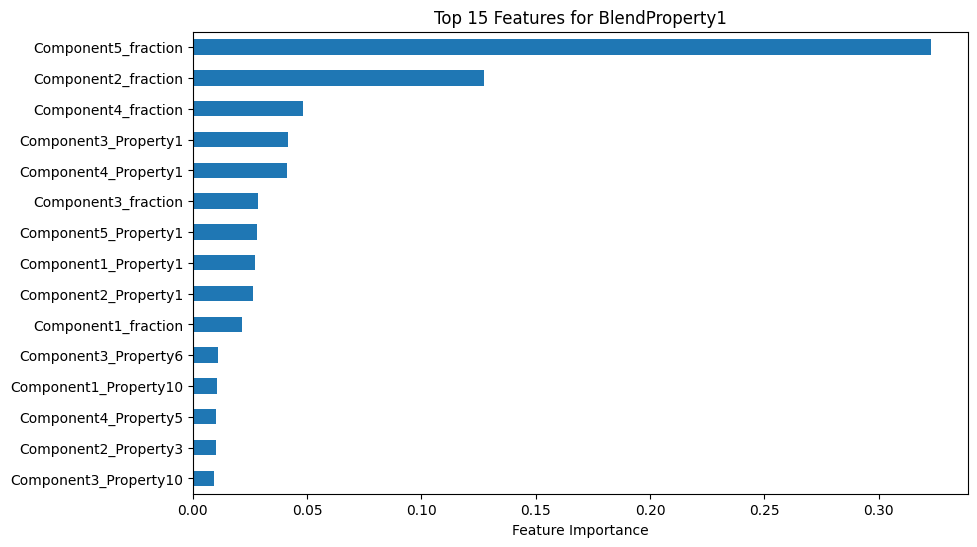

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

importance_1.head(15).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.title("Top 15 Features for BlendProperty1")
plt.show()

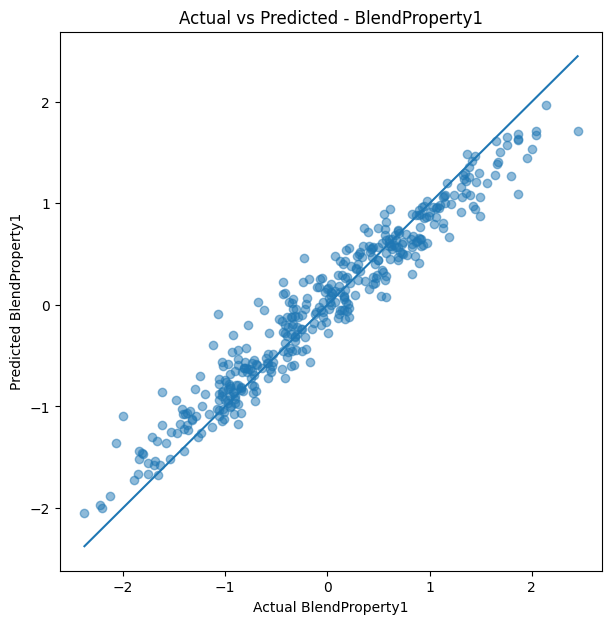

In [66]:
import matplotlib.pyplot as plt

y_actual = Y_val["BlendProperty1"]
y_pred = val_predictions[:, 0]

plt.figure(figsize=(7, 7))

plt.scatter(y_actual, y_pred, alpha=0.5)

# Perfect prediction line
minimum = min(y_actual.min(), y_pred.min())
maximum = max(y_actual.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum])

plt.xlabel("Actual BlendProperty1")
plt.ylabel("Predicted BlendProperty1")
plt.title("Actual vs Predicted - BlendProperty1")

plt.show()

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_actual = Y_val["BlendProperty1"]
y_pred = val_predictions[:, 0]

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.19742971483714936
RMSE: 0.2558541105102518
R²  : 0.9287884791495584


In [69]:
print("Minimum:", y_actual.min())
print("10th percentile:", y_actual.quantile(0.10))
print("Median:", y_actual.median())
print("Maximum:", y_actual.max())

Minimum: -2.3769625579426057
10th percentile: -1.2836073129547947
Median: -0.04751343723835655
Maximum: 2.449547698654964


In [70]:
print(
    "Values below 1:",
    (y_actual < 1).sum()
)

print(
    "Values below 0.5:",
    (y_actual < 0.5).sum()
)

Values below 1: 343
Values below 0.5: 277


In [72]:
from lightgbm import LGBMRegressor
import numpy as np
lgb_models = {}

lgb_val_predictions = np.zeros(
    (len(X_val), len(y_train.columns))
)

for i, target in enumerate(y_train.columns):

    print(f"Training LightGBM for {target}")

    lgb_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    lgb_model.fit(
        X_tr,
        Y_tr[target]
    )

    lgb_val_predictions[:, i] = lgb_model.predict(X_val)

    lgb_models[target] = lgb_model

print("All LightGBM models trained successfully!")

Training LightGBM for BlendProperty1
Training LightGBM for BlendProperty2
Training LightGBM for BlendProperty3
Training LightGBM for BlendProperty4
Training LightGBM for BlendProperty5
Training LightGBM for BlendProperty6
Training LightGBM for BlendProperty7
Training LightGBM for BlendProperty8
Training LightGBM for BlendProperty9
Training LightGBM for BlendProperty10
All LightGBM models trained successfully!


In [73]:
from sklearn.metrics import mean_absolute_percentage_error

lgb_mape = mean_absolute_percentage_error(
    Y_val,
    lgb_val_predictions
)

print("LightGBM Overall MAPE:", lgb_mape)

LightGBM Overall MAPE: 1.1377336900826105


In [74]:
ensemble_predictions = (
    0.5 * val_predictions +
    0.5 * lgb_val_predictions
)

In [76]:
ensemble_mape = mean_absolute_percentage_error(
    Y_val,
    ensemble_predictions
)

print("Ensemble MAPE:", ensemble_mape)

Ensemble MAPE: 1.8482902852408167


In [77]:
from sklearn.metrics import mean_absolute_percentage_error

weights = np.arange(0, 1.01, 0.1)

results = []

for w in weights:

    ensemble_predictions = (
        w * lgb_val_predictions +
        (1 - w) * val_predictions
    )

    mape = mean_absolute_percentage_error(
        Y_val,
        ensemble_predictions
    )

    results.append((w, mape))

for w, mape in results:
    print(
        f"LightGBM: {w:.1f} | "
        f"XGBoost: {1-w:.1f} | "
        f"MAPE: {mape:.4f}"
    )

LightGBM: 0.0 | XGBoost: 1.0 | MAPE: 2.6126
LightGBM: 0.1 | XGBoost: 0.9 | MAPE: 2.4575
LightGBM: 0.2 | XGBoost: 0.8 | MAPE: 2.3031
LightGBM: 0.3 | XGBoost: 0.7 | MAPE: 2.1494
LightGBM: 0.4 | XGBoost: 0.6 | MAPE: 1.9981
LightGBM: 0.5 | XGBoost: 0.5 | MAPE: 1.8483
LightGBM: 0.6 | XGBoost: 0.4 | MAPE: 1.7012
LightGBM: 0.7 | XGBoost: 0.3 | MAPE: 1.5560
LightGBM: 0.8 | XGBoost: 0.2 | MAPE: 1.4137
LightGBM: 0.9 | XGBoost: 0.1 | MAPE: 1.2751
LightGBM: 1.0 | XGBoost: 0.0 | MAPE: 1.1377


In [79]:
for i, target in enumerate(y_train.columns):

    mape = mean_absolute_percentage_error(
        Y_val[target],
        lgb_val_predictions[:, i]
    )

    print(f"{target}: {mape:.4f}")

BlendProperty1: 1.4986
BlendProperty2: 1.5079
BlendProperty3: 1.0631
BlendProperty4: 0.8297
BlendProperty5: 0.3118
BlendProperty6: 1.0580
BlendProperty7: 0.7345
BlendProperty8: 2.0155
BlendProperty9: 1.8301
BlendProperty10: 0.5281


In [80]:
lgb_models_tuned = {}

lgb_val_predictions_tuned = np.zeros(
    (len(X_val), len(y_train.columns))
)

for i, target in enumerate(y_train.columns):

    print(f"Training tuned LightGBM for {target}")

    model_lgb = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=7,
        num_leaves=40,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model_lgb.fit(
        X_tr,
        Y_tr[target]
    )

    lgb_val_predictions_tuned[:, i] = model_lgb.predict(X_val)

    lgb_models_tuned[target] = model_lgb

print("Tuned LightGBM training completed!")

Training tuned LightGBM for BlendProperty1
Training tuned LightGBM for BlendProperty2
Training tuned LightGBM for BlendProperty3
Training tuned LightGBM for BlendProperty4
Training tuned LightGBM for BlendProperty5
Training tuned LightGBM for BlendProperty6
Training tuned LightGBM for BlendProperty7
Training tuned LightGBM for BlendProperty8
Training tuned LightGBM for BlendProperty9
Training tuned LightGBM for BlendProperty10
Tuned LightGBM training completed!


In [81]:
tuned_lgb_mape = mean_absolute_percentage_error(
    Y_val,
    lgb_val_predictions_tuned
)

print("Tuned LightGBM MAPE:", tuned_lgb_mape)

Tuned LightGBM MAPE: 1.4022563021934138


In [82]:
X_test = test_df.drop(['ID'],axis=1)

In [83]:
X_test

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,Component1_Property9,Component2_Property9,Component3_Property9,Component4_Property9,Component5_Property9,Component1_Property10,Component2_Property10,Component3_Property10,Component4_Property10,Component5_Property10
0,0.18,0.05,0.32,0.37,0.08,-0.177804,-0.741219,0.769821,-0.877069,0.602809,...,-0.265376,0.123432,0.028533,-0.173365,1.297923,0.323299,-0.315146,0.625518,-0.514342,-0.777057
1,0.00,0.50,0.00,0.37,0.13,2.501354,0.177344,-0.498739,-0.196742,-1.943463,...,-0.787677,-0.757905,-0.280561,-1.965970,0.543475,-0.906851,0.962341,-0.183757,0.310871,-1.329042
2,0.16,0.00,0.17,0.50,0.17,1.547324,0.891479,0.030627,-0.368678,-0.294728,...,-0.710026,-1.422693,0.874071,-1.016144,0.093525,1.048525,-1.321851,0.356640,-0.869543,-0.177255
3,0.50,0.00,0.17,0.16,0.17,-0.424427,1.016862,-1.182979,-0.854225,-0.830186,...,-0.551366,0.257105,-0.077337,-0.721031,-0.760365,-0.507690,1.346556,-0.001529,-1.008445,1.726105
4,0.00,0.00,0.50,0.50,0.00,-0.187062,-0.762173,-0.473660,2.074087,0.756849,...,-1.811468,-0.181223,-0.475933,0.234775,-0.909020,1.238203,-1.805664,0.980417,-1.354932,-0.657513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.44,0.01,0.08,0.41,0.06,1.036797,1.415667,0.793302,-0.446630,0.395524,...,-2.690249,-0.231333,-1.365939,-0.853755,-1.344675,-1.947526,-1.074584,-0.421069,-0.603527,0.838356
496,0.19,0.47,0.03,0.23,0.08,-1.305137,-1.520941,-0.989537,0.903203,1.032029,...,-0.458610,-1.422693,1.952542,-0.283461,0.367323,2.689269,1.698609,-0.328886,-0.879281,-1.658223
497,0.43,0.01,0.12,0.21,0.23,0.806590,0.607324,0.359058,0.283394,1.032029,...,-0.437798,-0.810355,-0.926471,-1.480680,-1.613630,1.016878,0.989316,0.408454,-0.925924,-0.022020
498,0.03,0.04,0.42,0.42,0.09,-0.792140,0.674275,-1.783487,0.848296,0.164798,...,-2.507533,-0.080589,0.295430,-0.278889,-1.912659,0.090336,2.285824,0.793409,0.753718,-0.775325


In [88]:
final_lgb_models = {}
test_predictions = np.zeros((len(X_test), len(y_train.columns)))

for i, target in enumerate(y_train.columns):

    print(f"Training final model for {target}")

    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(x_train
              , y_train[target])

    # Save model
    final_lgb_models[target] = model

    # Predict test data
    test_predictions[:, i] = model.predict(X_test)

print("\nAll 10 final LightGBM models trained successfully!")
print("Prediction shape:", test_predictions.shape)

Training final model for BlendProperty1
Training final model for BlendProperty2
Training final model for BlendProperty3
Training final model for BlendProperty4
Training final model for BlendProperty5
Training final model for BlendProperty6
Training final model for BlendProperty7
Training final model for BlendProperty8
Training final model for BlendProperty9
Training final model for BlendProperty10

All 10 final LightGBM models trained successfully!
Prediction shape: (500, 10)


In [89]:
# Load the sample submission format
sample_submission = pd.read_csv("/content/sample_solution.csv")

# Get the 10 target column names
target_columns = y_train.columns.tolist()

# Fill predictions into the submission
for i, target in enumerate(target_columns):
    sample_submission[target] = test_predictions[:, i]

# Save submission file
submission_path = "/content/submission.csv"
sample_submission.to_csv(submission_path, index=False)

print("Submission created successfully!")
print("Shape:", sample_submission.shape)

print("\nColumns:")
print(sample_submission.columns.tolist())

print("\nFirst 5 rows:")
display(sample_submission.head())

Submission created successfully!
Shape: (500, 11)

Columns:
['ID', 'BlendProperty1', 'BlendProperty2', 'BlendProperty3', 'BlendProperty4', 'BlendProperty5', 'BlendProperty6', 'BlendProperty7', 'BlendProperty8', 'BlendProperty9', 'BlendProperty10']

First 5 rows:


,ID,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,1,0.022558,0.309468,0.677674,0.303503,0.317622,0.633775,0.702536,0.255188,-0.273715,0.356635
1,2,-0.480458,-0.602085,-1.196491,-0.147773,-0.735726,-0.069261,-1.168980,-1.200343,-0.441837,0.063289
2,3,1.498679,0.934920,1.034847,1.010994,2.330381,1.669784,0.996124,1.752474,0.172650,2.112699
3,4,-0.380157,0.165268,0.522787,-0.404796,1.922673,-0.240939,0.425999,0.904534,0.656205,-1.030584
4,5,-0.010510,-0.801650,1.070322,0.329350,2.505726,0.194974,1.019504,-0.084980,-0.671682,1.105181


In [90]:
# Check for missing values
print("Missing values:")
print(sample_submission.isnull().sum())

print("\nSubmission shape:", sample_submission.shape)

print("\nUnique IDs:", sample_submission["ID"].nunique())

print("\nTotal rows:", len(sample_submission))

Missing values:
ID                 0
BlendProperty1     0
BlendProperty2     0
BlendProperty3     0
BlendProperty4     0
BlendProperty5     0
BlendProperty6     0
BlendProperty7     0
BlendProperty8     0
BlendProperty9     0
BlendProperty10    0
dtype: int64

Submission shape: (500, 11)

Unique IDs: 500

Total rows: 500
